In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("new.csv")

In [3]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [4]:
X=df.drop('Temperature' , axis=1)
y=df['Temperature']

In [5]:
X.head()

,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.25 , random_state=42)

In [8]:
scaler = StandardScaler()

In [9]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
model=LinearRegression()


In [12]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred=model.predict(X_test)

In [14]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [15]:
mae=mean_absolute_error(y_test , y_pred)
score=r2_score(y_test , y_pred)

In [16]:
mae,score

(2.1190792066390265, 0.4110840434744292)

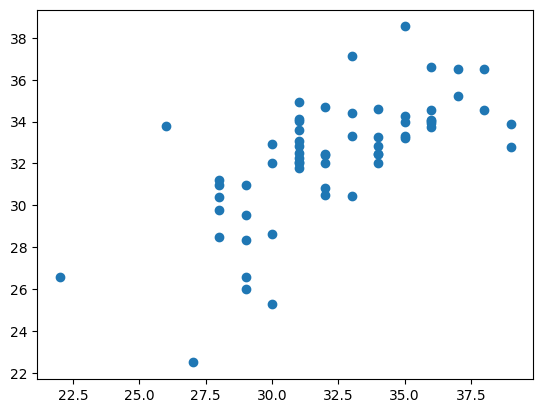

In [17]:
plt.scatter(y_test , y_pred)

In [18]:
from sklearn.linear_model import Lasso

In [19]:
model_ls=Lasso()

In [20]:
model_ls.fit(X_train , y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [21]:
y_pred_ls=model.predict(X_test)

In [22]:
mae_ls=mean_absolute_error(y_test , y_pred_ls)
score_ls=r2_score(y_test , y_pred_ls)

In [23]:
mae_ls , score_ls

(2.1190792066390265, 0.4110840434744292)

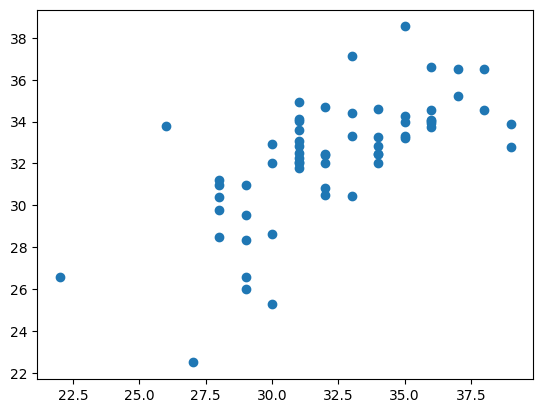

In [24]:
plt.scatter(y_test , y_pred)

In [25]:
import joblib

In [26]:
joblib.dump(model_ls , 'model_ls.pkl')


['model_ls.pkl']

In [27]:
joblib.dump(model , 'model.pkl')

['model.pkl']